In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
import math

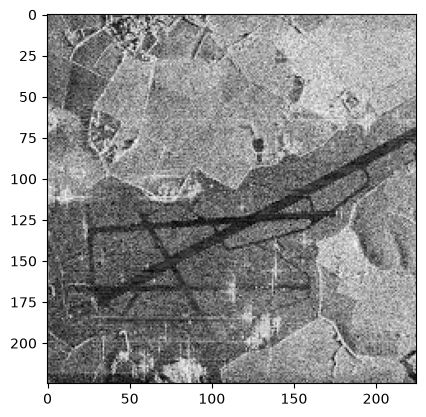

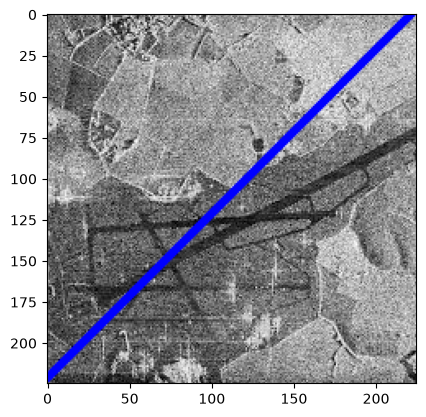

Наиболее протяженный участок (rho, theta): [156.          0.7853982]


In [3]:
# Наиболее протяженный участок через преобразование Хафа 
image = cv2.imread(r"C:\Users\arago\Desktop\leaning\home\sar_3.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

canny = cv2.Canny(image_gray, 50, 150, apertureSize=3)

lines = cv2.HoughLines(canny, 1, np.pi / 180, 120)

image_longest = copy.deepcopy(image)
if lines is not None:
    rho = lines[0][0][0]
    theta = lines[0][0][1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))
    cv2.line(image_longest, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

plt.imshow(image_longest)
plt.show()

print("Наиболее протяженный участок (rho, theta):", lines[0][0])


In [ ]:
# Бинаризация, выделение дорожной полосы
# Точечная бинаризация
bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.imshow(bin_img, cmap="gray")
plt.show()

# Отсу
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(th2, cmap="gray")
plt.show()

# Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 71, 21)
plt.imshow(th3, cmap="gray")
plt.show()

# Выделение участка дорожной полосы
road_mask = copy.deepcopy(image)
road_mask[th3 == 255] = [0, 255, 0]

plt.imshow(road_mask)
plt.show()

NameError: name 'copy' is not defined